In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

X shape: torch.Size([190, 10, 1])  y shape: torch.Size([190, 1])
Train: 152, Test: 38


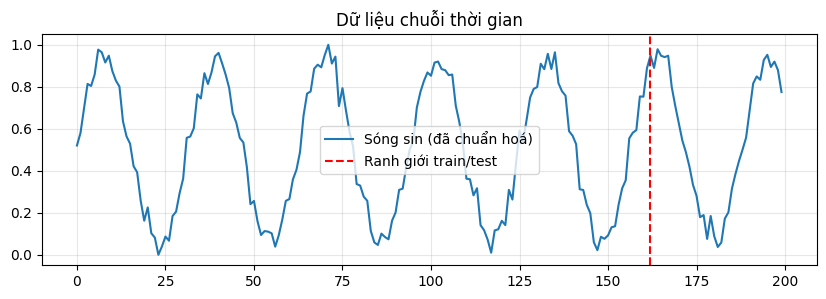

In [2]:
time_steps = 200
x = np.linspace(0, 40, time_steps)
data = np.sin(x) + 0.1 * np.random.randn(time_steps)

# Chuẩn hoá min-max về [0, 1] để output sigmoid hoặc tanh dễ học hơn.
data_min, data_max = data.min(), data.max()
data = (data - data_min) / (data_max - data_min)
data = torch.FloatTensor(data).unsqueeze(1)   # shape (200, 1)

def create_sequences(series, seq_length):
    X, y = [], []
    for i in range(len(series) - seq_length):
        X.append(series[i : i + seq_length])
        y.append(series[i + seq_length])
    return torch.stack(X), torch.stack(y)

seq_length = 10
X, y = create_sequences(data, seq_length)
print('X shape:', X.shape, ' y shape:', y.shape)   # (190, 10, 1) và (190, 1)

# Chia 80/20.
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
print(f'Train: {len(X_train)}, Test: {len(X_test)}')

# Vẽ chuỗi gốc để có cảm giác về dữ liệu.
plt.figure(figsize=(10, 3))
plt.plot(data.numpy(), label='Sóng sin (đã chuẩn hoá)')
plt.axvline(train_size + seq_length, color='red', linestyle='--', label='Ranh giới train/test')
plt.legend(); plt.grid(alpha=0.3); plt.title('Dữ liệu chuỗi thời gian')
plt.show()

In [3]:
class RNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=20, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # PyTorch tự khởi tạo h0 = 0 nếu mình không truyền vào.
        out, _ = self.rnn(x)             # out shape: (batch, seq_len, hidden_size)
        out = self.fc(out[:, -1, :])     # chỉ lấy bước cuối cùng → (batch, output_size)
        return out

model = RNN()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
print(model)

RNN(
  (rnn): RNN(1, 20, batch_first=True)
  (fc): Linear(in_features=20, out_features=1, bias=True)
)


In [4]:
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=16, shuffle=True)

num_epochs = 100
loss_history = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    n_samples = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * X_batch.size(0)
        n_samples += X_batch.size(0)

    avg_loss = epoch_loss / n_samples
    loss_history.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1:3d}/{num_epochs}] loss = {avg_loss:.5f}')

Epoch [ 10/100] loss = 0.00300
Epoch [ 20/100] loss = 0.00271
Epoch [ 30/100] loss = 0.00258
Epoch [ 40/100] loss = 0.00329
Epoch [ 50/100] loss = 0.00299
Epoch [ 60/100] loss = 0.00275
Epoch [ 70/100] loss = 0.00305
Epoch [ 80/100] loss = 0.00259
Epoch [ 90/100] loss = 0.00256
Epoch [100/100] loss = 0.00276


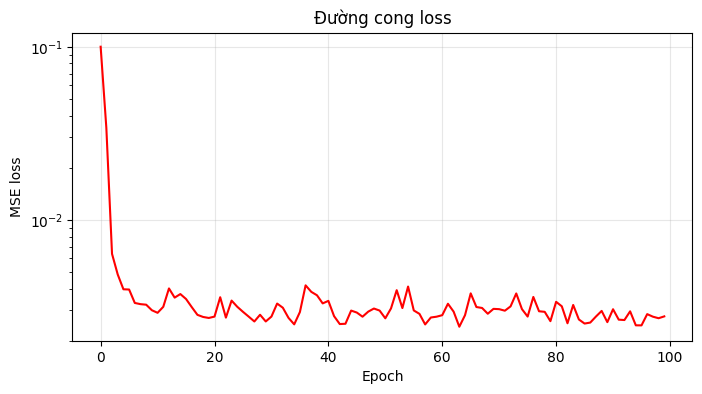

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history, color='red')
plt.xlabel('Epoch'); plt.ylabel('MSE loss'); plt.title('Đường cong loss')
plt.grid(alpha=0.3); plt.yscale('log')
plt.show()

In [6]:
model.eval()
with torch.no_grad():
    pred_one_step = model(X_test).squeeze().numpy()
    truth        = y_test.squeeze().numpy()

mse = np.mean((pred_one_step - truth) ** 2)
mae = np.mean(np.abs(pred_one_step - truth))
print(f'One-step MSE = {mse:.5f},  MAE = {mae:.5f}')

# Baseline ngây thơ: "giá trị tiếp theo bằng giá trị cuối cùng đã thấy".
naive_pred = X_test[:, -1, 0].numpy()
mse_naive = np.mean((naive_pred - truth) ** 2)
print(f'Baseline (naive) MSE = {mse_naive:.5f}  ← RNN phải đánh bại con số này mới gọi là học được gì.')

One-step MSE = 0.00235,  MAE = 0.04097
Baseline (naive) MSE = 0.00600  ← RNN phải đánh bại con số này mới gọi là học được gì.


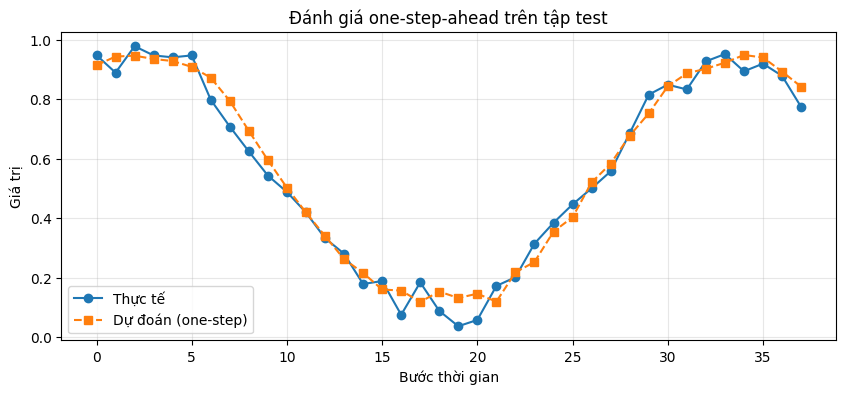

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(truth, 'o-', label='Thực tế')
plt.plot(pred_one_step, 's--', label='Dự đoán (one-step)')
plt.title('Đánh giá one-step-ahead trên tập test')
plt.xlabel('Bước thời gian'); plt.ylabel('Giá trị')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

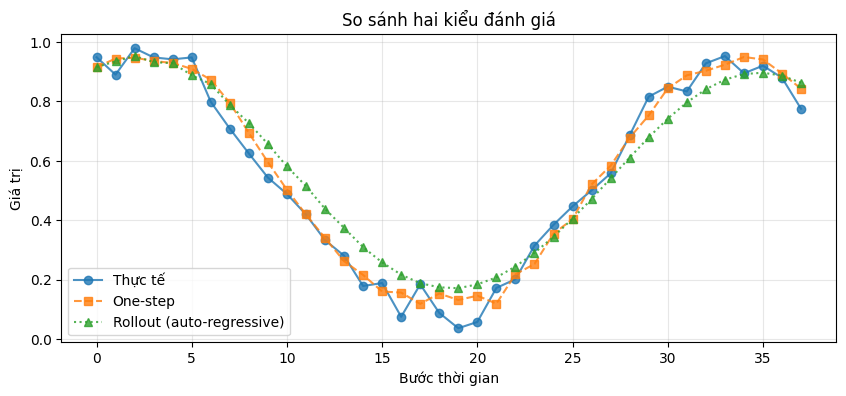

One-step MSE: 0.00235
Rollout  MSE: 0.00604  ← lớn hơn nhiều, đúng như dự đoán.


In [8]:
model.eval()
rollout = []
with torch.no_grad():
    inputs = X_test[0].unsqueeze(0).clone()   # shape (1, 10, 1)
    for _ in range(len(X_test)):
        out = model(inputs)                   # (1, 1)
        rollout.append(out.item())
        # Đẩy out vào cuối, bỏ phần tử đầu — cửa sổ trượt 1 bước.
        next_step = out.unsqueeze(0)          # (1, 1, 1)
        inputs = torch.cat([inputs[:, 1:, :], next_step], dim=1)

rollout = np.array(rollout)

plt.figure(figsize=(10, 4))
plt.plot(truth,           'o-', label='Thực tế', alpha=0.8)
plt.plot(pred_one_step,   's--', label='One-step', alpha=0.8)
plt.plot(rollout,         '^:', label='Rollout (auto-regressive)', alpha=0.8)
plt.title('So sánh hai kiểu đánh giá')
plt.xlabel('Bước thời gian'); plt.ylabel('Giá trị')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

print(f'One-step MSE: {mse:.5f}')
print(f'Rollout  MSE: {np.mean((rollout - truth)**2):.5f}  ← lớn hơn nhiều, đúng như dự đoán.')

   feature_1  feature_2  feature_3    target
0   0.000000   1.000000   0.049671  0.268485
1   0.100166   0.998742  -0.008810  0.319935
2   0.199325   0.994971   0.074802  0.450479
3   0.296479   0.988696   0.167353  0.508837
4   0.390650   0.979933  -0.003348  0.487590


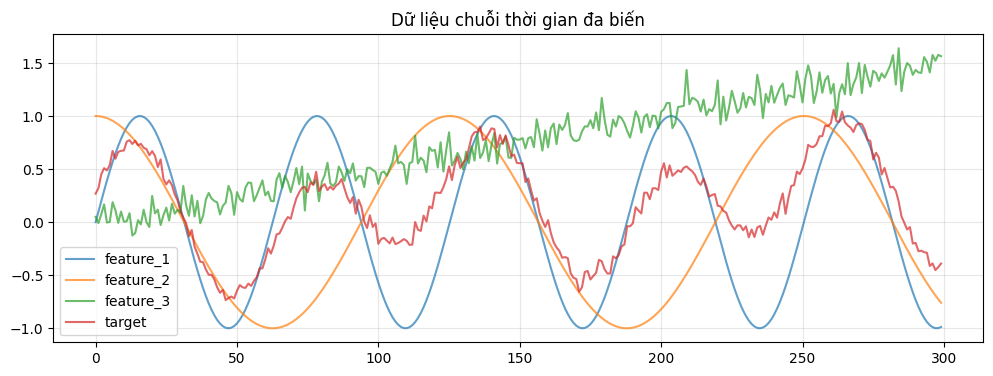

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

time_steps = 300
t = np.linspace(0, 30, time_steps)
feature_1 = np.sin(t)
feature_2 = np.cos(0.5 * t)
feature_3 = 0.05 * t + 0.1 * np.random.randn(time_steps)
target = 0.5 * feature_1 + 0.3 * feature_2 + 0.2 * feature_3 + 0.05 * np.random.randn(time_steps)

df = pd.DataFrame({
    'feature_1': feature_1,
    'feature_2': feature_2,
    'feature_3': feature_3,
    'target': target,
})
print(df.head())

plt.figure(figsize=(12, 4))
for col in df.columns:
    plt.plot(df[col], label=col, alpha=0.7)
plt.legend(); plt.grid(alpha=0.3)
plt.title('Dữ liệu chuỗi thời gian đa biến')
plt.show()